In [1]:
%load_ext autoreload
%autoreload 2
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from DShap import DShap
from shap_utils import *
import sys
import time
from Shapley import ShapNN
from DShap import DShap
import sklearn
from sklearn.datasets import load_wine
import numpy as np
from sklearn.preprocessing import MinMaxScaler
warnings.filterwarnings("ignore")
# -------------------------------
# Parameters
# -------------------------------
train_size = 100         # number of training samples
directory = './real_data_results' # folder for saving plots/files
os.makedirs(directory, exist_ok=True)
# -------------------------------
# Load dataset
# -------------------------------
data = load_breast_cancer()
X_raw, y_raw = data.data, data.target
X, y = X_raw[:train_size], y_raw[:train_size]
X_test, y_test = X_raw[train_size:], y_raw[train_size:]
# # -------------------------------
# Train logistic regression
# -------------------------------
%matplotlib inline
MEM_DIR = './'
problem, model = 'classification', 'vyngoc' # 'logistic'
hidden_units = [] # Empty list in the case of logistic regression.
d, difficulty = 50, 1
num_classes = 2
tol = 0.03
important_dims = 5
clf = return_model(model, solver='liblinear', hidden_units=tuple(hidden_units))
clf.fit(X, y)
test_acc = clf.score(X_test, y_test)
num_test = len(y_test)
print("Full Data Size:", len(y_raw))
print("Training Data Size:", len(y))
print("Test Size:", len(y_test))
print("Performance using the whole training set = {:.2f}".format(test_acc))
print("Training class counts:", np.bincount(y))
print("Test class counts:", np.bincount(y_test))

Instructions for updating:
non-resource variables are not supported in the long term
Full Data Size: 569
Training Data Size: 100
Test Size: 469
Performance using the whole training set = 0.31
Training class counts: [65 35]
Test class counts: [147 322]


In [2]:
print(X,y)

[[1.799e+01 1.038e+01 1.228e+02 ... 2.654e-01 4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 ... 1.860e-01 2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 ... 2.430e-01 3.613e-01 8.758e-02]
 ...
 [9.787e+00 1.994e+01 6.211e+01 ... 2.381e-02 1.934e-01 8.988e-02]
 [1.160e+01 1.284e+01 7.434e+01 ... 8.449e-02 2.772e-01 8.756e-02]
 [1.442e+01 1.977e+01 9.448e+01 ... 1.565e-01 2.718e-01 9.353e-02]] [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0]


In [3]:
import pandas as pd
train_df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
train_df['label'] = y
test_df = pd.DataFrame(X_test, columns=[f"feature_{i}" for i in range(X_test.shape[1])])
test_df['label'] = y_test
print("=== Training DataFrame ===")
print(train_df)
print("\n=== Test DataFrame ===")
print(test_df)

=== Training DataFrame ===
    feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0      17.990      10.38     122.80     1001.0    0.11840    0.27760   
1      20.570      17.77     132.90     1326.0    0.08474    0.07864   
2      19.690      21.25     130.00     1203.0    0.10960    0.15990   
3      11.420      20.38      77.58      386.1    0.14250    0.28390   
4      20.290      14.34     135.10     1297.0    0.10030    0.13280   
..        ...        ...        ...        ...        ...        ...   
95     20.260      23.03     132.40     1264.0    0.09078    0.13130   
96     12.180      17.84      77.79      451.1    0.10450    0.07057   
97      9.787      19.94      62.11      294.5    0.10240    0.05301   
98     11.600      12.84      74.34      412.6    0.08983    0.07525   
99     14.420      19.77      94.48      642.5    0.09752    0.11410   

    feature_6  feature_7  feature_8  feature_9  ...  feature_21  feature_22  \
0    0.300100   0.147100     

In [4]:
print("=== Training set statistics ===")
train_stats = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
train_stats['label'] = y
print(train_stats.describe())
print("\n=== Test set statistics ===")
test_stats = pd.DataFrame(X_test, columns=[f"feature_{i}" for i in range(X_test.shape[1])])
test_stats['label'] = y_test
print(test_stats.describe())

=== Training set statistics ===
        feature_0   feature_1   feature_2    feature_3   feature_4  \
count  100.000000  100.000000  100.000000   100.000000  100.000000   
mean    14.707780   19.692200   96.471200   703.293000    0.102040   
std      3.349245    3.759176   23.187471   320.152301    0.013151   
min      8.196000   10.380000   51.710000   201.900000    0.073550   
25%     12.457500   16.760000   82.270000   476.800000    0.093402   
50%     14.335000   20.190000   94.365000   643.650000    0.101150   
75%     17.155000   22.150000  114.400000   916.875000    0.110375   
max     25.220000   27.540000  171.500000  1878.000000    0.142500   

        feature_5   feature_6   feature_7   feature_8   feature_9  ...  \
count  100.000000  100.000000  100.000000  100.000000  100.000000  ...   
mean     0.126576    0.114752    0.063801    0.193070    0.064670  ...   
std      0.061123    0.078862    0.038104    0.030822    0.008168  ...   
min      0.037660    0.000692    0.004167

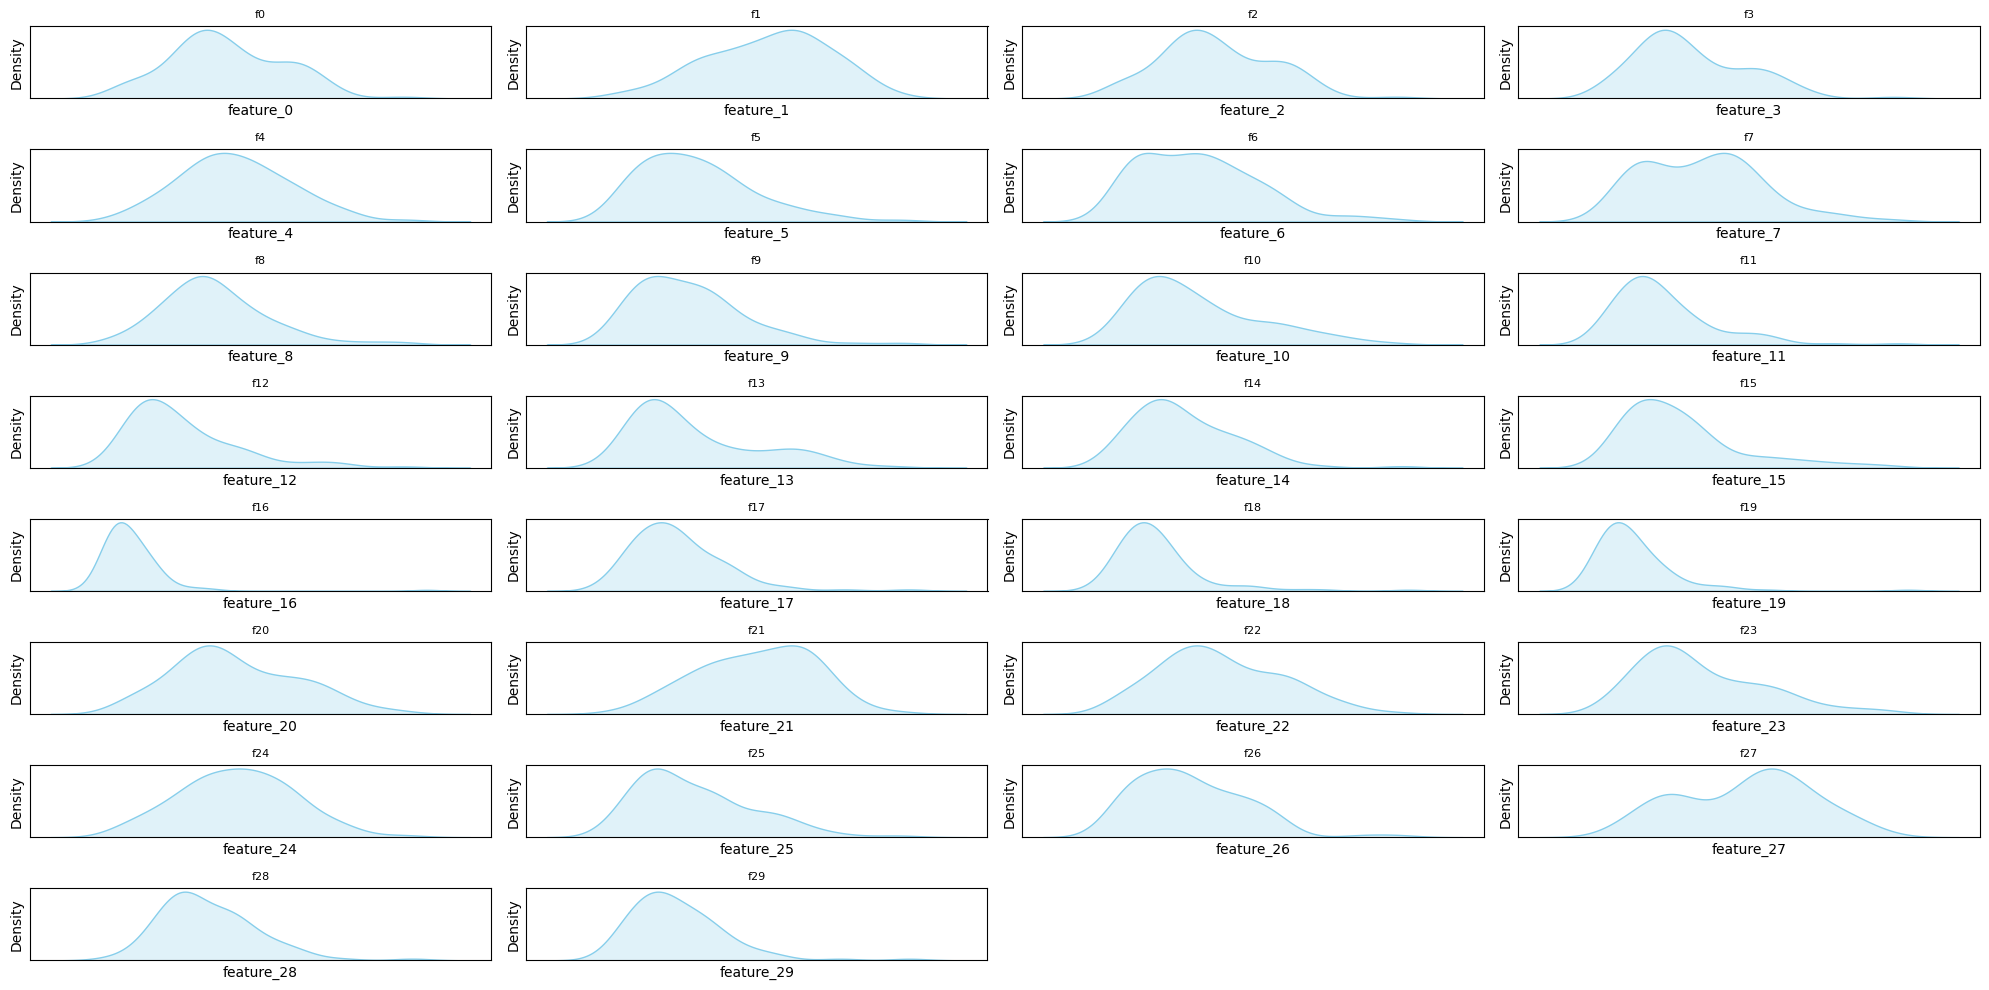

In [5]:
%matplotlib inline

import seaborn as sns
import matplotlib.pyplot as plt

num_features = X.shape[1]  
cols = 4  
rows = int(np.ceil(num_features / cols))  

plt.figure(figsize=(20, 10)) 

for i in range(num_features):
    plt.subplot(rows, cols, i+1)
    sns.kdeplot(train_df[f"feature_{i}"], fill=True, color='skyblue')
    plt.title(f'f{i}', fontsize=8)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()

In [6]:
dshap = DShap(X, y, X_test, y_test, num_test, 
              sources=None, 
              sample_weight=None,
              model_family=model, 
              metric='accuracy',
              overwrite=True,
              directory=directory, seed=0)
dshap.run(50, 0.1)
dshap = DShap(X, y, X_test, y_test, num_test, model_family=model, metric='accuracy',
              directory=directory, seed=1)
dshap.run(50, 0.1)
dshap = DShap(X, y, X_test, y_test, num_test, model_family=model, metric='accuracy',
              directory=directory, seed=2)
dshap.run(50, 0.1)
dshap.merge_results()

Starting LOO score calculations!
LOO values calculated!
5 out of 50 G-Shapley iterations
10 out of 50 G-Shapley iterations
15 out of 50 G-Shapley iterations
20 out of 50 G-Shapley iterations
25 out of 50 G-Shapley iterations
30 out of 50 G-Shapley iterations
35 out of 50 G-Shapley iterations
40 out of 50 G-Shapley iterations
45 out of 50 G-Shapley iterations
50 out of 50 G-Shapley iterations
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 G-Shapley iterations
10 out of 50 G-Shapley iterations
15 out of 50 G-Shapley iterations
20 out of 50 G-Shapley iterations
25 out of 50 G-Shapley iterations
30 out of 50 G-Shapley iterations
35 out of 50 G-Shapley iterations

5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 o

40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 o

25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 o

25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 o

5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 o

20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 o

5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 o

25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 o

50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 out of 50 TMC_Shapley iterations.
40 out of 50 TMC_Shapley iterations.
45 out of 50 TMC_Shapley iterations.
50 out of 50 TMC_Shapley iterations.
5 out of 50 TMC_Shapley iterations.
10 out of 50 TMC_Shapley iterations.
15 out of 50 TMC_Shapley iterations.
20 out of 50 TMC_Shapley iterations.
25 out of 50 TMC_Shapley iterations.
30 out of 50 TMC_Shapley iterations.
35 o

In [7]:
dshap.merge_results()

./real_data_results/mem_tmc_0000.pkl
./real_data_results/mem_g_0000.pkl


(None, None)

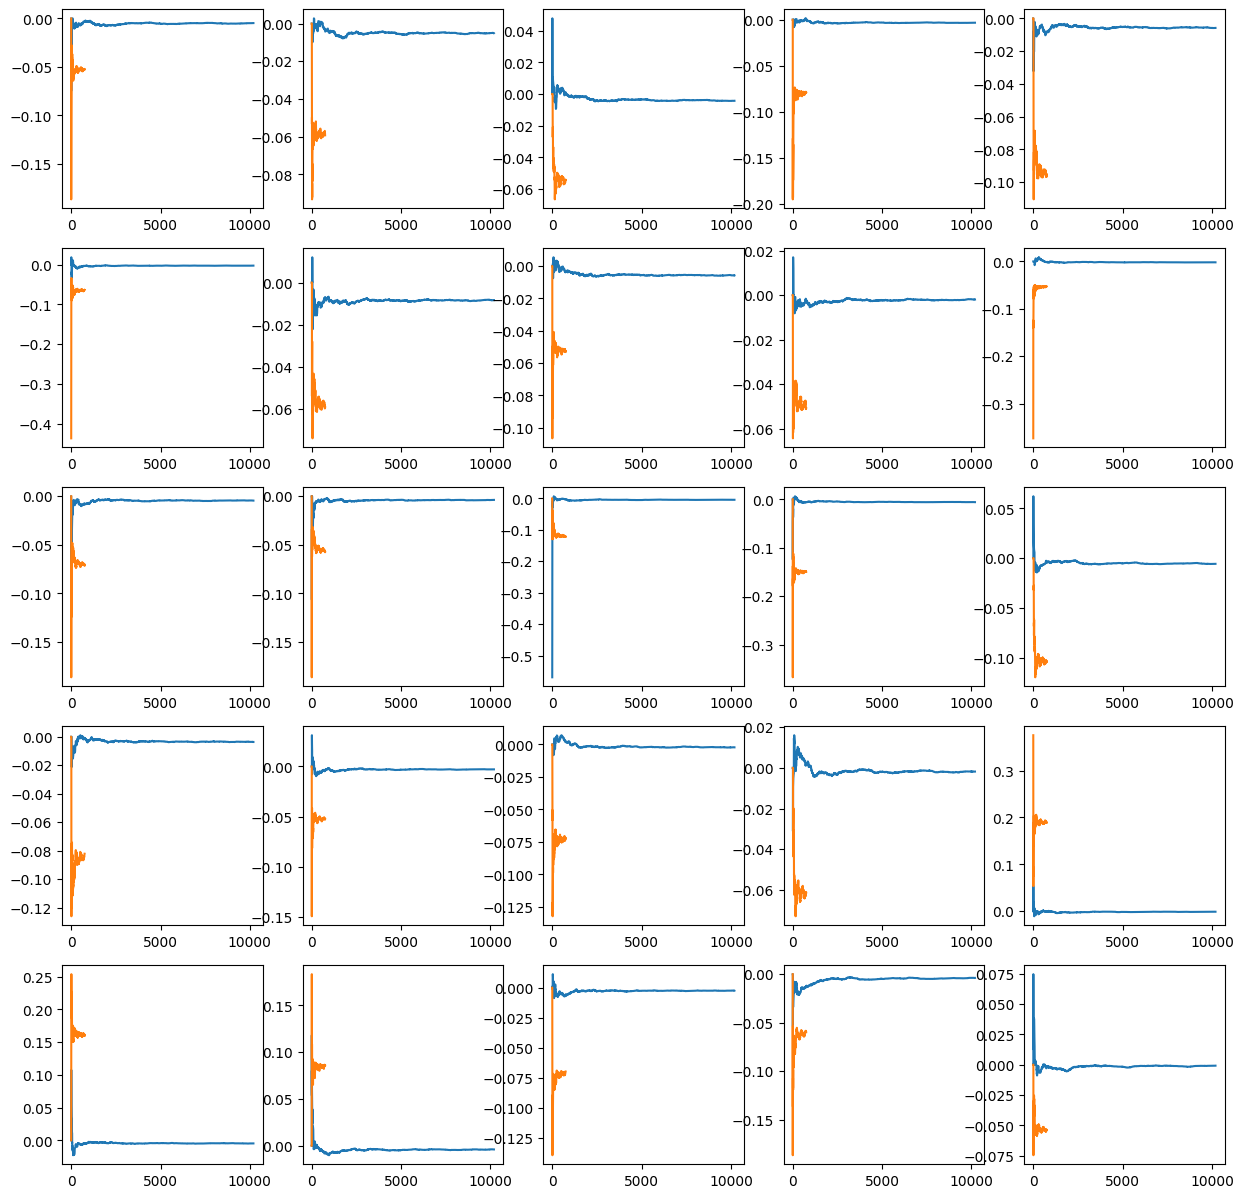

In [8]:
%matplotlib inline
convergence_plots(dshap.marginals_tmc),convergence_plots(dshap.marginals_g)

In [9]:
len(dshap.vals_tmc),len(dshap.vals_g),len(dshap.vals_loo)

(100, 100, 100)

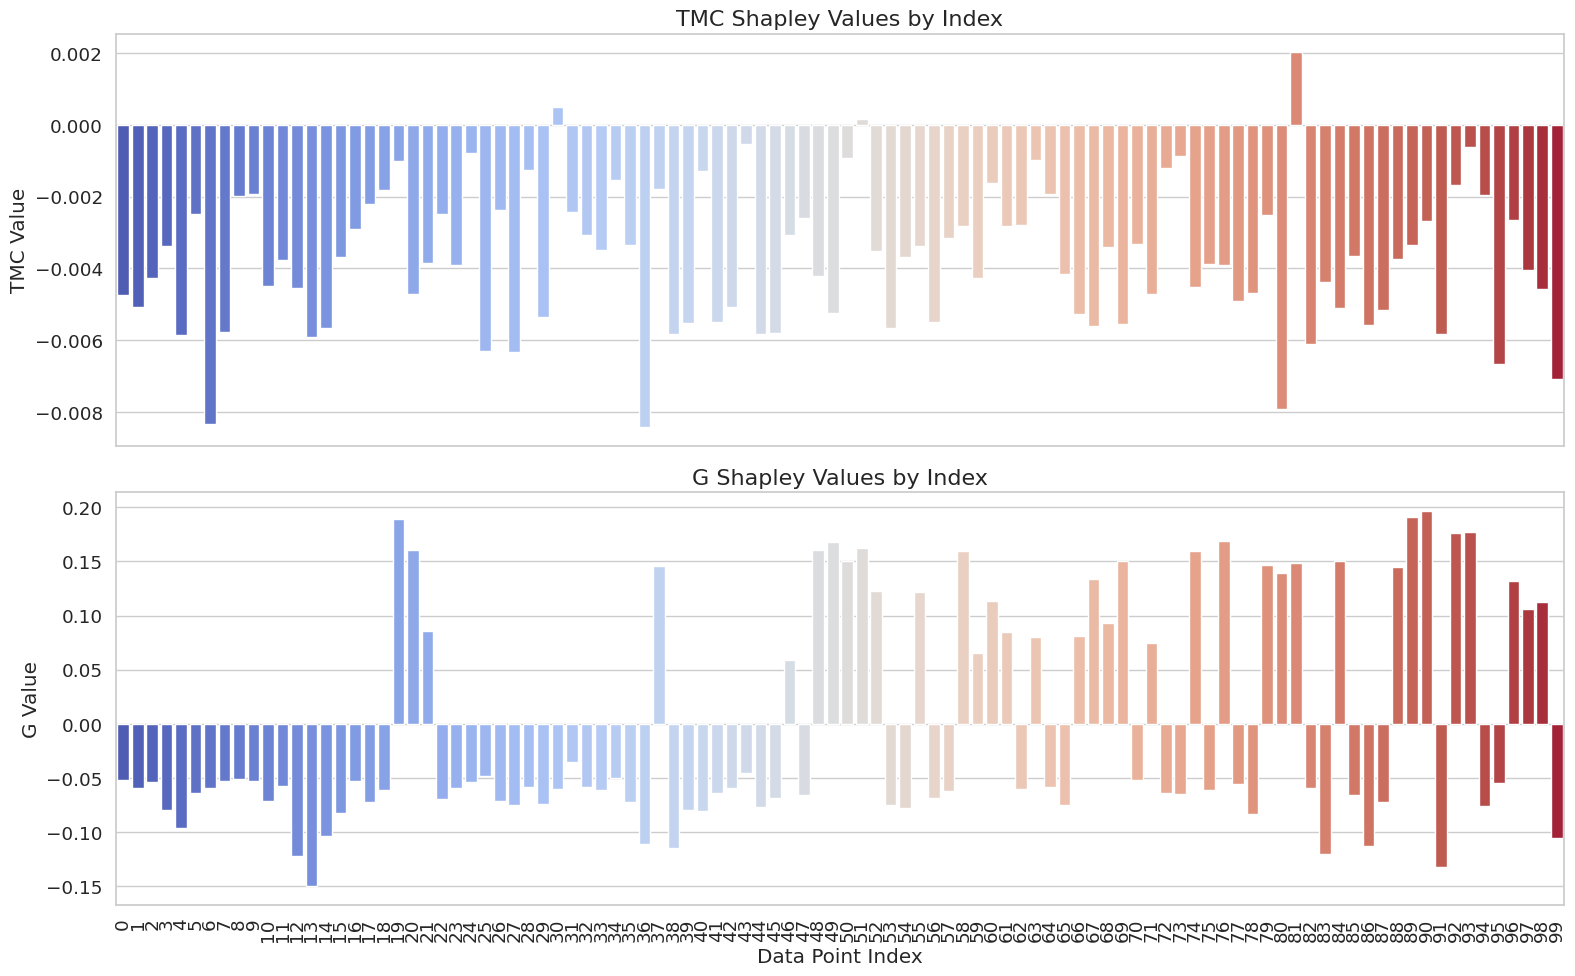

In [10]:
vals_tmc = np.array(dshap.vals_tmc)
vals_g = np.array(dshap.vals_g)
# Create a DataFrame with original indices
df = pd.DataFrame({
    'Index': np.arange(len(vals_tmc)),
    'TMC': vals_tmc,
    'G': vals_g
})
# Initialize Seaborn style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
# Create figure with 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
# Plot TMC values
sns.barplot(x='Index', y='TMC', data=df, palette='coolwarm', ax=axes[0])
axes[0].set_title("TMC Shapley Values by Index", fontsize=16)
axes[0].set_ylabel("TMC Value")
axes[0].set_xlabel("")
# Plot G values
sns.barplot(x='Index', y='G', data=df, palette='coolwarm', ax=axes[1])
axes[1].set_title("G Shapley Values by Index", fontsize=16)
axes[1].set_ylabel("G Value")
axes[1].set_xlabel("Data Point Index")
# Beautify layout
plt.xticks(rotation=90)
plt.tight_layout()
# Save figure
os.makedirs("real_data_results", exist_ok=True)
plt.savefig("real_data_results/tmc_vs_g_separate_real_raw.png", bbox_inches='tight')
plt.show()

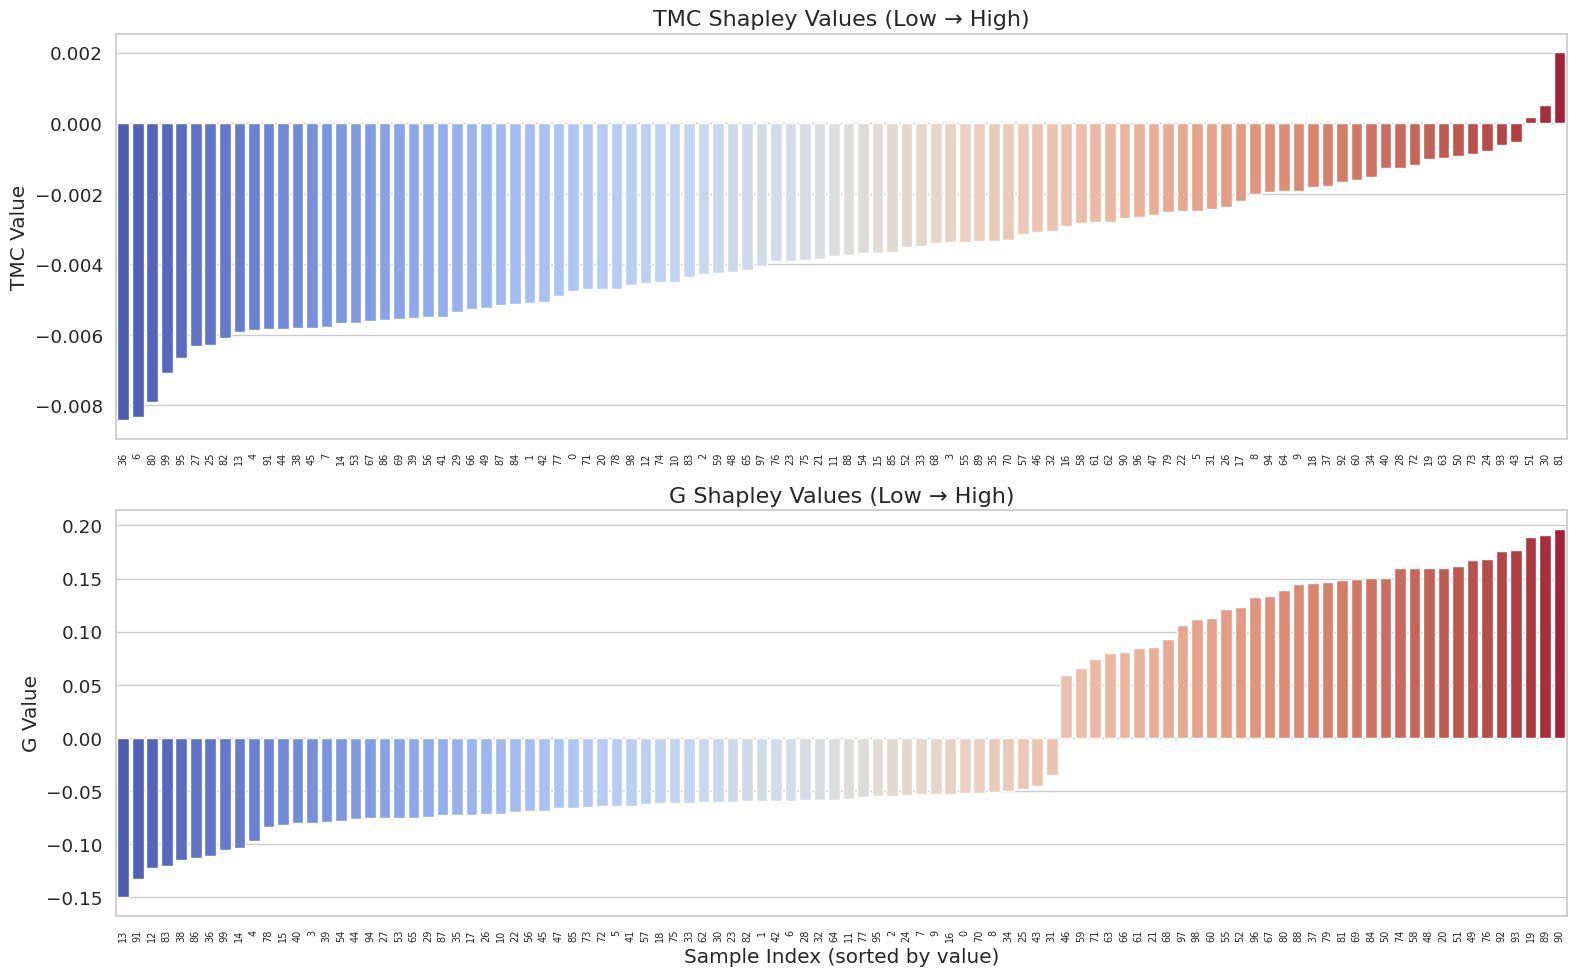

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
vals_tmc = np.array(dshap.vals_tmc)
vals_g = np.array(dshap.vals_g)
# Create DataFrame with original indices
df = pd.DataFrame({
    'Index': np.arange(len(vals_tmc)),
    'TMC': vals_tmc,
    'G': vals_g
})
# Initialize Seaborn style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
# Create figure with 2 subplots
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
# --- TMC sorted (low → high) ---
df_sorted_tmc = df.sort_values(by='TMC', ascending=True).reset_index(drop=True)
sns.barplot(x=df_sorted_tmc.index, y='TMC', data=df_sorted_tmc, palette='coolwarm', ax=axes[0])
axes[0].set_title("TMC Shapley Values (Low → High)", fontsize=16)
axes[0].set_ylabel("TMC Value")
axes[0].set_xlabel("")
# Show original sample index as tick labels
axes[0].set_xticks(range(len(df_sorted_tmc)))
axes[0].set_xticklabels(df_sorted_tmc['Index'], rotation=90, fontsize=7)
# --- G sorted (low → high) ---
df_sorted_g = df.sort_values(by='G', ascending=True).reset_index(drop=True)
sns.barplot(x=df_sorted_g.index, y='G', data=df_sorted_g, palette='coolwarm', ax=axes[1])
axes[1].set_title("G Shapley Values (Low → High)", fontsize=16)
axes[1].set_ylabel("G Value")
axes[1].set_xlabel("Sample Index (sorted by value)")
# Show original sample index as tick labels
axes[1].set_xticks(range(len(df_sorted_g)))
axes[1].set_xticklabels(df_sorted_g['Index'], rotation=90, fontsize=7)
plt.tight_layout()
# Save figure
os.makedirs("real_data_results", exist_ok=True)
plt.savefig("real_data_results/tmc_vs_g_sorted_real_raw.png", bbox_inches='tight')
plt.show()

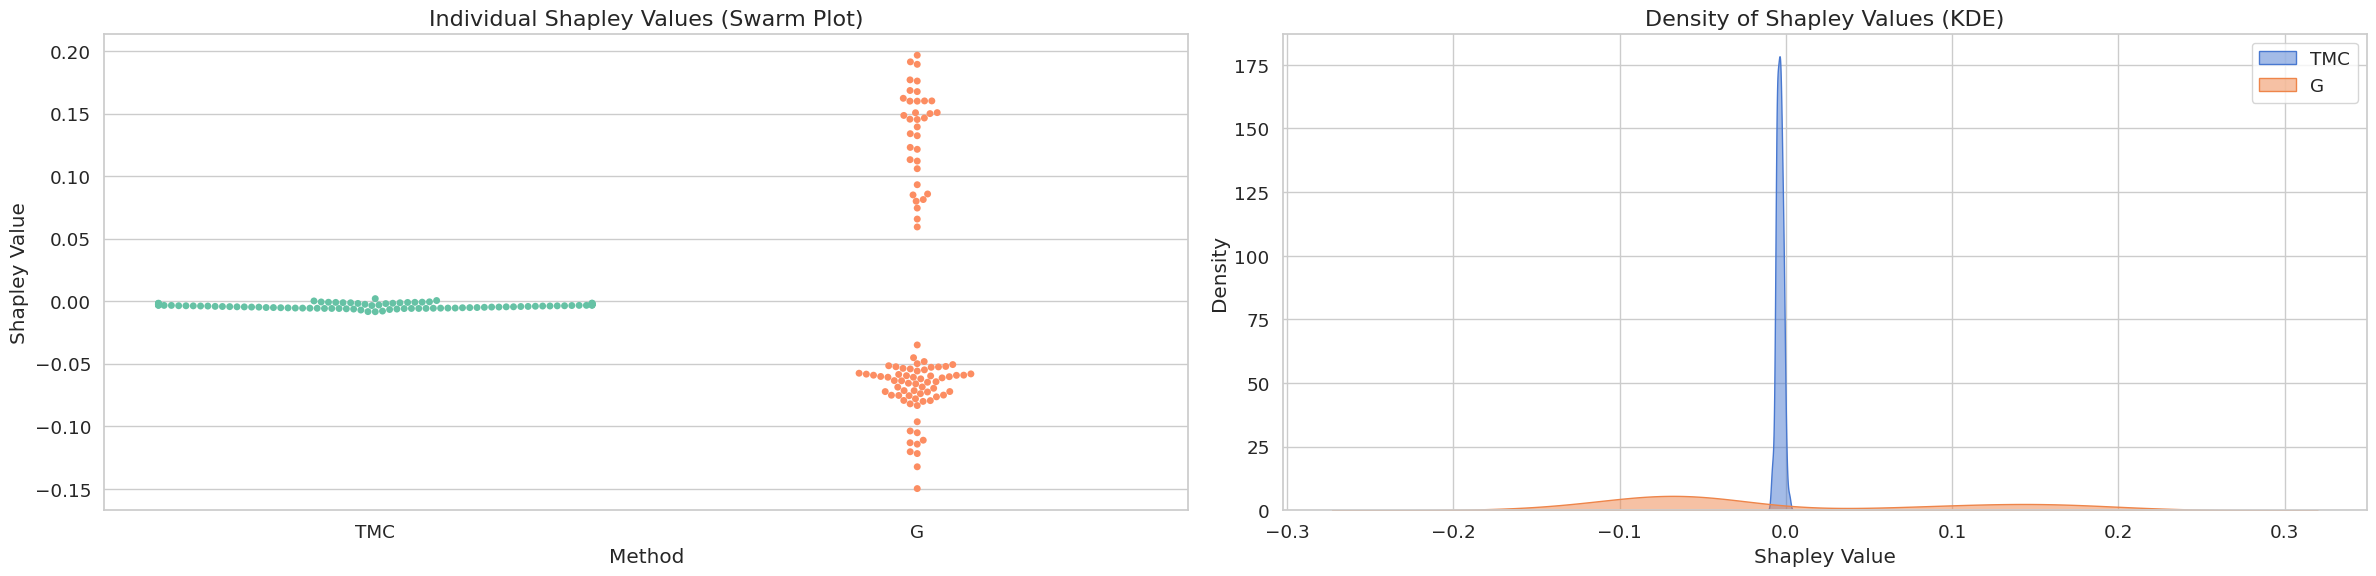

In [12]:
vals_tmc = np.array(dshap.vals_tmc)
vals_g = np.array(dshap.vals_g)
# Create a DataFrame
df = pd.DataFrame({
    'TMC': vals_tmc,
    'G': vals_g,
})
# Set Seaborn style
sns.set(style="whitegrid", palette="muted", font_scale=1.2)
# Create a figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 6))
# 1. Swarm plot (individual points)
sns.swarmplot(data=df, palette="Set2", size=5, ax=axes[0])
axes[0].set_title("Individual Shapley Values (Swarm Plot)", fontsize=16)
axes[0].set_ylabel("Shapley Value")
axes[0].set_xlabel("Method")
# 2. KDE plot (density estimate)
for method in df.columns:
    sns.kdeplot(df[method], fill=True, label=method, alpha=0.5, ax=axes[1])
axes[1].set_title("Density of Shapley Values (KDE)", fontsize=16)
axes[1].set_ylabel("Density")
axes[1].set_xlabel("Shapley Value")
axes[1].legend()
plt.tight_layout()
# Save figure
output_dir = "real_data_results"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "shapley_plots_real_raw.png"), bbox_inches='tight')
plt.show()

Training samples: 100
Test samples: 469
Baseline performance: 0.3134


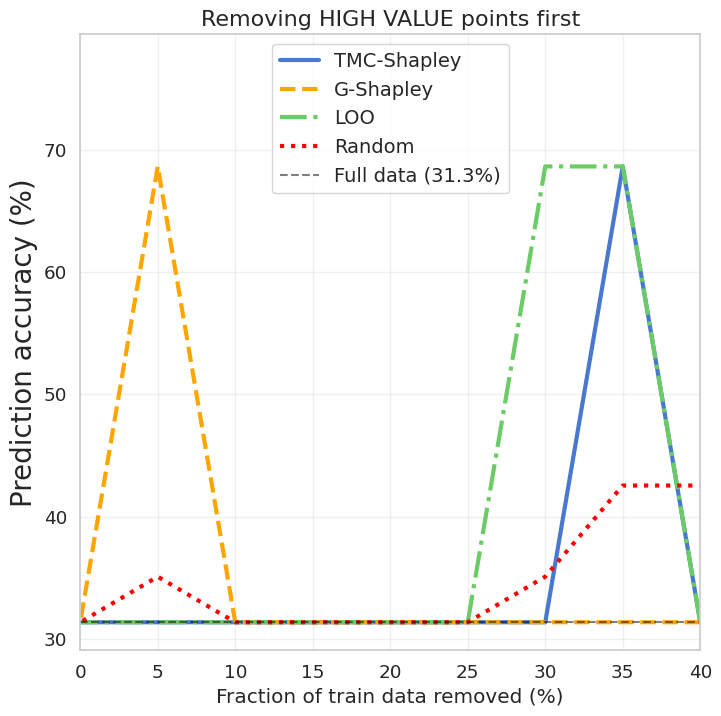

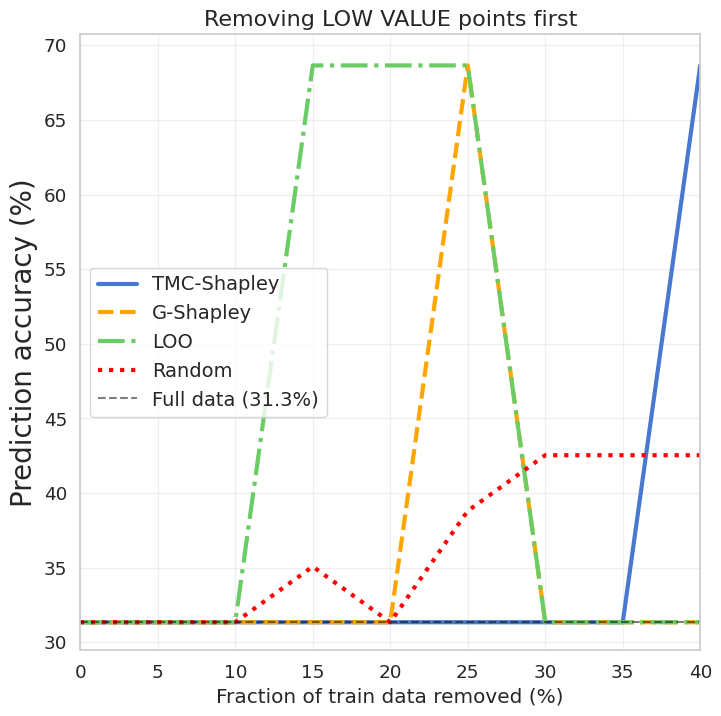

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
%matplotlib inline
class realdataEvaluator:
    def __init__(self, X_train, y_train, X_test, y_test, model=None, directory=None):
        self.X = X_train
        self.y = y_train
        self.X_heldout = X_test
        self.y_heldout = y_test
        self.directory = directory        
        print(f"Training samples: {len(self.X)}")
        print(f"Test samples: {len(self.X_heldout)}")   
        self.model = clf            
        self.metric = accuracy_score
        self.baseline_performance = self._get_baseline_performance()
        print(f"Baseline performance: {self.baseline_performance:.4f}")        
    def _get_baseline_performance(self):
        self.restart_model()
        self.model.fit(self.X, self.y)
        return self.metric(self.y_heldout, self.model.predict(self.X_heldout))
    def restart_model(self):
        self.model = clf    
    def performance_plots_remove_low_value(self, vals, name=None, num_plot_markers=20, sources=None):
        plt.rcParams.update({'figure.figsize': (8, 8), 'font.size': 25})
        plt.xlabel('Fraction of train data removed (%)')
        plt.ylabel('Prediction accuracy (%)', fontsize=20)
        plt.title('Removing LOW VALUE points first', fontsize=16)
        if not isinstance(vals, (list, tuple)):
            vals = [vals]        
        if sources is None:
            sources = {i: np.array([i]) for i in range(len(self.X))}
        elif not isinstance(sources, dict):
            sources = {i: np.where(sources == i)[0] for i in set(sources)}
        vals_sources = [np.array([np.mean(val[sources[i]]) for i in range(len(sources))]) for val in vals]
        n_total = len(sources)
        plot_points = np.unique(np.linspace(0, n_total, num_plot_markers + 1).astype(int))
        if 0 not in plot_points: plot_points = np.insert(plot_points, 0, 0)
        if n_total not in plot_points: plot_points = np.append(plot_points, n_total)        
        perfs = []
        for vals_source in vals_sources:
            sorted_idx_high_to_low = np.argsort(vals_source)[::-1]
            perf = self._portion_performance(sorted_idx_high_to_low, plot_points, sources)
            perfs.append(perf)        
        rnd = np.mean([self._portion_performance(np.random.permutation(n_total), plot_points, sources) for _ in range(10)], 0)
        colors = ['b', 'orange', 'g']
        linestyles = ['-', '--', '-.']
        labels = ['TMC-Shapley', 'G-Shapley', 'LOO']
        removal_pct = (1 - plot_points / n_total) * 100
        for i in range(len(perfs)):
            plt.plot(
                removal_pct, 
                perfs[i] * 100, 
                linestyle=linestyles[i], 
                lw=3, 
                color=colors[i], 
                label=labels[i]
            )
        plt.plot(removal_pct, rnd * 100, ':', lw=3, color='red', label='Random')
        plt.axhline(
            y=self.baseline_performance * 100, 
            color='black', 
            linestyle='--', 
            alpha=0.5, 
            label=f'Full data ({self.baseline_performance*100:.1f}%)'
        )
        plt.legend(loc='best', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 40)
        if self.directory and name:
            os.makedirs(os.path.join(self.directory, 'plots'), exist_ok=True)
            plt.savefig(os.path.join(self.directory, 'plots', f'{name}_remove_low_value.png'), bbox_inches='tight', dpi=300)
            plt.show()
        else:
            plt.show()        
        return perfs, rnd    
    def performance_plots_remove_high_value(self, vals, name=None, num_plot_markers=20, sources=None):
        plt.rcParams.update({'figure.figsize': (8, 8), 'font.size': 25})
        plt.xlabel('Fraction of train data removed (%)')
        plt.ylabel('Prediction accuracy (%)', fontsize=20)
        plt.title('Removing HIGH VALUE points first', fontsize=16)        
        if not isinstance(vals, (list, tuple)):
            vals = [vals]        
        if sources is None:
            sources = {i: np.array([i]) for i in range(len(self.X))}
        elif not isinstance(sources, dict):
            sources = {i: np.where(sources == i)[0] for i in set(sources)}        
        vals_sources = [np.array([np.mean(val[sources[i]]) for i in range(len(sources))]) for val in vals]
        n_total = len(sources)
        plot_points = np.unique(np.linspace(0, n_total, num_plot_markers + 1).astype(int))
        if 0 not in plot_points: plot_points = np.insert(plot_points, 0, 0)
        if n_total not in plot_points: plot_points = np.append(plot_points, n_total)        
        perfs = []
        for vals_source in vals_sources:
            sorted_idx_low_to_high = np.argsort(vals_source)   # most negative first
            perf = self._portion_performance(sorted_idx_low_to_high, plot_points, sources)
            perfs.append(perf)        
        rnd = np.mean([self._portion_performance(np.random.permutation(n_total), plot_points, sources) for _ in range(10)], 0)
        colors = ['b', 'orange', 'g']
        linestyles = ['-', '--', '-.']
        labels = ['TMC-Shapley', 'G-Shapley', 'LOO']
        removal_pct = (1 - plot_points / n_total) * 100
        for i in range(len(perfs)):
            plt.plot(
                removal_pct, 
                perfs[i] * 100, 
                linestyle=linestyles[i], 
                lw=3, 
                color=colors[i], 
                label=labels[i]
            )
        plt.plot(removal_pct, rnd * 100, ':', lw=3, color='red', label='Random')
        plt.axhline(
            y=self.baseline_performance * 100, 
            color='black', 
            linestyle='--', 
            alpha=0.5, 
            label=f'Full data ({self.baseline_performance*100:.1f}%)'
        )        
        plt.legend(loc='best', fontsize=14)
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 40)        
        if self.directory and name:
            os.makedirs(os.path.join(self.directory, 'plots'), exist_ok=True)
            plt.savefig(os.path.join(self.directory, 'plots', f'{name}_remove_high_value.png'), bbox_inches='tight', dpi=300)
            plt.show()
        else:
            plt.show()        
        return perfs, rnd    
    def _portion_performance(self, sorted_idx, plot_points, sources):
        if self.y_heldout is None or len(self.y_heldout) == 0:
            return np.array([0.1] * len(plot_points))        
        scores = []
        total_sources = len(sources)        
        for num_keep in plot_points:
            keep_count = int(num_keep)            
            if keep_count == 0:
                majority_class = np.argmax(np.bincount(self.y_heldout.astype(int)))
                scores.append(np.mean(self.y_heldout == majority_class))
                continue
            keep_source_indices = sorted_idx[:keep_count]                
            keep_idxs = np.concatenate([sources[idx] for idx in keep_source_indices if idx < len(sources)])
            if len(keep_idxs) == 0:
                majority_class = np.argmax(np.bincount(self.y_heldout.astype(int)))
                scores.append(np.mean(self.y_heldout == majority_class))
                continue
            X_batch, y_batch = self.X[keep_idxs], self.y[keep_idxs]
            if len(np.unique(y_batch)) < 2:
                scores.append(np.mean(self.y_heldout == np.unique(y_batch)[0]))
                continue
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                self.restart_model()
                self.model.fit(X_batch, y_batch)
                scores.append(self.metric(self.y_heldout, self.model.predict(self.X_heldout)))
        return np.array(scores)
if __name__ == "__main__":
    X_train = X
    y_train = y    
    evaluator = realdataEvaluator(X_train, y_train, X_test, y_test, directory="./real_data_results")
    vals_tmc = dshap.vals_tmc
    vals_g = dshap.vals_g
    vals_loo = dshap.vals_loo
    evaluator.performance_plots_remove_high_value(vals=[vals_tmc, vals_g, vals_loo], name="breast_cancer_remove_high_value_raw", num_plot_markers=20)
    evaluator.performance_plots_remove_low_value(vals=[vals_tmc, vals_g, vals_loo], name="breast_cancer_remove_low_value_raw", num_plot_markers=20)